In [ ]:
215510P-Athapaththu AAND

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image

In [15]:
import numpy as np
import requests
from io import StringIO

BASE = "https://raw.githubusercontent.com/NalinDhanuddheera/Assignment-2---Fitting-and-Alignment/main/data"

def load_csv_from_github(raw_url):
    response = requests.get(raw_url)
    if response.status_code == 200:
        print(f"Loaded successfully: {raw_url.split('/')[-1]}")
        return np.genfromtxt(StringIO(response.text), delimiter=",", skip_header=1)
    else:
        print(f"Failed to load: {response.status_code}")
        return None





Q1(b)

In [27]:
# Load lines.csv 
csv_url = f"{BASE}/lines.csv"
D = load_csv_from_github(csv_url)

X_cols = D[:, :3]
Y_cols = D[:, 3:]

# check
print(f"\nData shape: {D.shape}")
print(f"First row: {D[:5]}")

Loaded successfully: lines.csv

Data shape: (100, 6)
First row: [[ -5.30547099  -4.06009155  -5.26129006 -12.66633342  -3.79615021
    3.69171161]
 [ -5.5403588   -5.0031803   -3.99259187 -11.00772693  -3.98562503
    4.90000402]
 [ -4.98212753  -4.58449362  -4.33122591 -11.69731474  -3.58927699
    5.04686274]
 [ -4.49570614  -5.06413838  -4.78201809 -11.97801037  -3.59707103
    4.63593624]
 [ -4.44215386  -4.41137023  -4.5675092  -12.41495176  -2.79950409
    4.73969871]]


Q1(b)


    Fit a line ax + by + c = 0  (with a^2 + b^2 = 1)
    using Total Least Squares via SVD.

    Steps:
    1. Centre the data by subtracting the mean
    2. Apply SVD to the centred data matrix
    3. Normal vector = last row of Vt (smallest singular value)
    4. Find c using the centroid condition

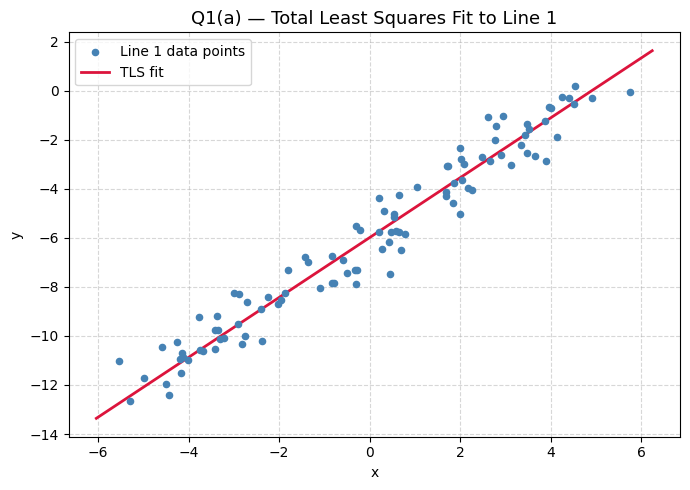

In [36]:

# ── Use only first line data (column 0) 
x1 = D[:, 0]    
y1 = D[:, 3]    

# Total Least Squares using SVD
def total_least_squares(x, y):

    # centre the data
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    A      = np.column_stack([x - x_mean, y - y_mean])

    # SVD
    _, _, Vt = np.linalg.svd(A)

    # normal direction = last row of Vt
    a, b = Vt[-1]

    # c from centroid condition: a*x_mean + b*y_mean + c = 0
    c = -(a * x_mean + b * y_mean)

    return a, b, c

# Fit line to Line 1 data 
a, b, c = total_least_squares(x1, y1)

if abs(b) > 1e-9:
    m = -a / b
    k = -c / b
    

# Plot
x_plot = np.linspace(x1.min() - 0.5, x1.max() + 0.5, 200)
y_plot = m * x_plot + k

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(x1, y1,
            color='steelblue', s=20,
            label='Line 1 data points', zorder=3)
ax.plot(x_plot, y_plot,
        color='crimson', linewidth=2,
        label=f'TLS fit')
ax.set_title('Q1(a) — Total Least Squares Fit to Line 1', fontsize=13)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Q1(b)

Total mixed points: 300

Q1b — RANSAC Results:
Line 1: a=-0.445405,  b=-0.895329,  c=1.804913
         y = -0.4975x + 2.0159  |  inliers = 69
Line 2: a=0.718067,  b=-0.695974,  c=0.728210
         y = 1.0317x + 1.0463  |  inliers = 56
Line 3: a=0.784311,  b=-0.620368,  c=-3.613804
         y = 1.2643x + -5.8253  |  inliers = 57
Remaining unclassified points: 118


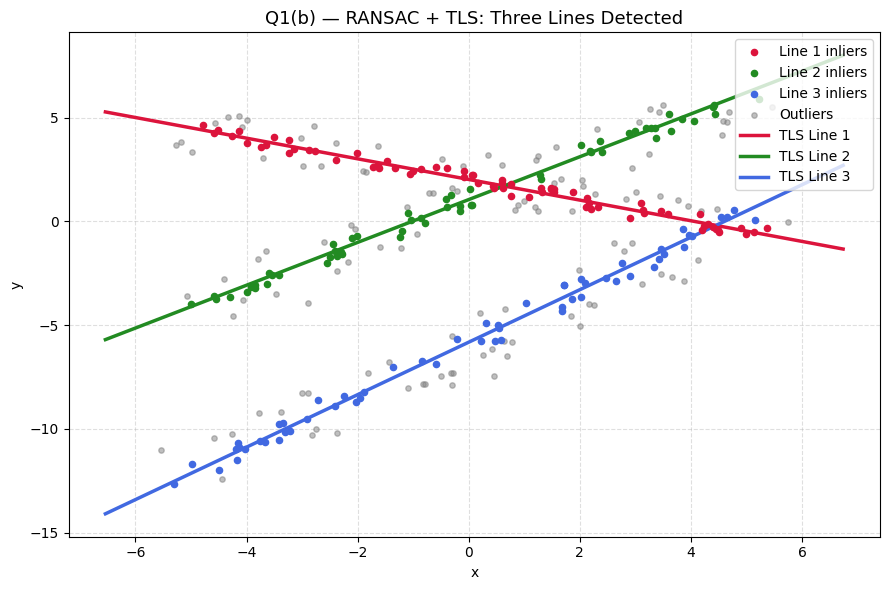

In [37]:
import random

X_all = X_cols.flatten()
Y_all = Y_cols.flatten()
print(f"Total mixed points: {len(X_all)}")

def point_to_line_distance(x, y, a, b, c):
    """Perpendicular distance from points (x,y) to line ax+by+c=0."""
    return np.abs(a * x + b * y + c) / np.sqrt(a**2 + b**2)


def ransac_fit_line(x, y, n_iter=2000, threshold=0.4, min_inliers=10):
    best_mask   = np.zeros(len(x), dtype=bool)
    best_count  = 0
    best_params = None
    n           = len(x)

    for _ in range(n_iter):
        # minimal sample: 2 random points
        idx     = random.sample(range(n), 2)
        xs, ys  = x[idx], y[idx]

        # fit line through 2 points (direction vector)
        dx   = xs[1] - xs[0]
        dy   = ys[1] - ys[0]
        norm = np.sqrt(dx**2 + dy**2)
        if norm < 1e-9:
            continue
        a =  -dy / norm
        b =   dx / norm
        c = -(a * xs[0] + b * ys[0])

        # count inliers
        dist  = point_to_line_distance(x, y, a, b, c)
        mask  = dist < threshold
        count = np.sum(mask)

        if count > best_count:
            best_count  = count
            best_mask   = mask
            best_params = (a, b, c)

    if best_params is None or best_count < min_inliers:
        return None, None

    # refit TLS on all inliers
    a_ref, b_ref, c_ref = fit_line_tls(
        np.column_stack([x[best_mask], y[best_mask]])
    )

    # Recompute final mask with refined parameters
    dist_ref   = point_to_line_distance(x, y, a_ref, b_ref, c_ref)
    final_mask = dist_ref < threshold

    return (a_ref, b_ref, c_ref), final_mask

random.seed(42)
np.random.seed(42)

active = np.ones(len(X_all), dtype=bool)  
lines  = []
masks  = []
colors = ['crimson', 'forestgreen', 'royalblue']

print("\nQ1b — RANSAC Results:")
print("=" * 55)

for i in range(3):
    x_cur = X_all[active]
    y_cur = Y_all[active]

    params, mask_local = ransac_fit_line(x_cur, y_cur,n_iter=2000,threshold=0.4)

    if params is None:
        print(f"RANSAC failed to find line {i+1}")
        break

    a, b, c = params

    # Map local inlier indices back to global indices
    global_idx    = np.where(active)[0]
    inlier_global = global_idx[mask_local]

    lines.append(params)
    masks.append(inlier_global)

    # Mask out this consensus set for next iteration
    active[inlier_global] = False

    print(f"Line {i+1}: a={a:.6f},  b={b:.6f},  c={c:.6f}")
    if abs(b) > 1e-9:
        print(f"         y = {-a/b:.4f}x + {-c/b:.4f}"
                f"  |  inliers = {np.sum(mask_local)}")

print("=" * 55)
print(f"Remaining unclassified points: {np.sum(active)}")

# Plotting the results
fig, ax = plt.subplots(figsize=(9, 6))

# Plot inliers for each line
for i, (params, idx, col) in enumerate(zip(lines, masks, colors)):
    ax.scatter(X_all[idx], Y_all[idx],color=col, s=20,label=f'Line {i+1} inliers',zorder=3)

# Plot outliers (unclassified points)
outlier_mask = np.ones(len(X_all), dtype=bool)
for idx in masks:
    outlier_mask[idx] = False
ax.scatter(X_all[outlier_mask], Y_all[outlier_mask],
        color='gray', s=15, alpha=0.5,
        label='Outliers', zorder=2)

# Draw fitted lines across the data range
x_range = np.linspace(X_all.min() - 1, X_all.max() + 1, 300)
for i, (params, col) in enumerate(zip(lines, colors)):
    a, b, c = params
    if abs(b) > 1e-9:
        y_line = (-a * x_range - c) / b
        ax.plot(x_range, y_line,
                color=col, linewidth=2.5,
                label=f'TLS Line {i+1}')

ax.set_title('Q1(b) — RANSAC + TLS: Three Lines Detected', fontsize=13)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend(loc='upper right')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()